In [1]:
!pip install tensorflow pillow matplotlib numpy

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Розмір навчального набору: (60000, 28, 28, 1)
Розмір тестового набору: (10000, 28, 28, 1)


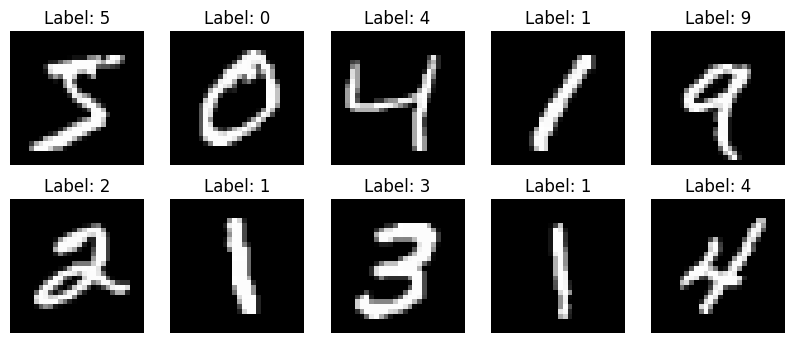

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
844/844 - 44s - 52ms/step - accuracy: 0.9365 - loss: 0.2153 - val_accuracy: 0.9853 - val_loss: 0.0569
Epoch 2/3
844/844 - 41s - 49ms/step - accuracy: 0.9805 - loss: 0.0634 - val_accuracy: 0.9855 - val_loss: 0.0500
Epoch 3/3
844/844 - 41s - 48ms/step - accuracy: 0.9856 - loss: 0.0468 - val_accuracy: 0.9888 - val_loss: 0.0382


mnist_base_model.h5
Loss: 0.03829227760434151
Accuracy: 0.9876999855041504
Epoch 1/5
844/844 - 46s - 55ms/step - accuracy: 0.9343 - loss: 0.2134 - val_accuracy: 0.9827 - val_loss: 0.0610
Epoch 2/5
844/844 - 82s - 97ms/step - accuracy: 0.9786 - loss: 0.0706 - val_accuracy: 0.9895 - val_loss: 0.0370
Epoch 3/5
844/844 - 82s - 97ms/step - accuracy: 0.9845 - loss: 0.0491 - val_accuracy: 0.9890 - val_loss: 0.0358
Epoch 4/5
844/844 - 81s - 95ms/step - accuracy: 0.9881 - loss: 0.0387 - val_accuracy: 0.9907 - val_loss: 0.0361
Epoch 5/5
844/844 - 43s - 51ms/step - accuracy: 0.9901 - loss: 0.0310 - val_accuracy: 0.9908 - val_loss: 0.0338


mnist_improved_model.h5
Loss: 0.030492626130580902
Accuracy: 0.9889000058174133
Точність базової моделі: 0.9876999855041504
Точність покращеної моделі: 0.9889000058174133
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
Правильні відповіді:  [7 2 1 0 4 1 4 9 5 9]
Прогноз моделі:       [7 2 1 0 4 1 4 9 5 9]


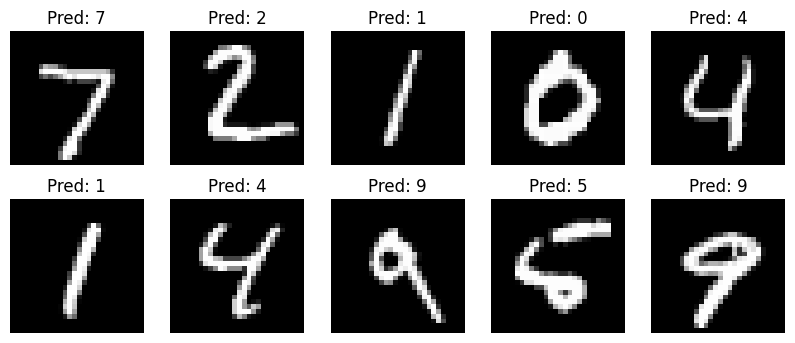

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Точність по кожній цифрі:
0 : 0.9969
1 : 0.9991
2 : 0.9922
3 : 0.9871
4 : 0.9959
5 : 0.9776
6 : 0.9885
7 : 0.9912
8 : 0.9846
9 : 0.9732
Найкраще модель розпізнає цифру: 1
Найгірше модель розпізнає цифру: 9


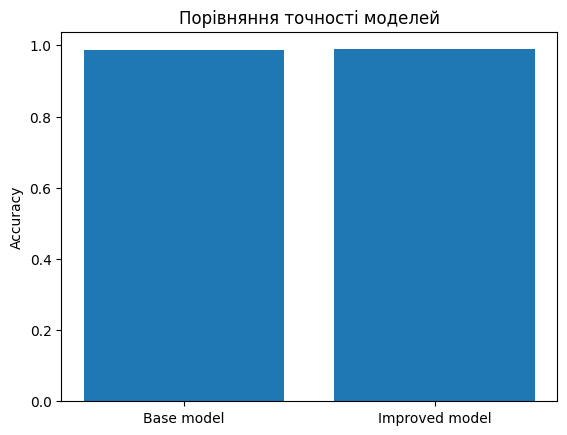

README.txt створено
Моделі збережено у файли mnist_base_model.h5 та mnist_improved_model.h5


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from PIL import Image


# ---------- 1. Підготовка даних ----------

def prepare_data():
    """Завантажує MNIST і готує картинки до навчання."""
    (x_train, y_train), (x_test, y_test) = mnist.load_data()

    x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255
    x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255

    return x_train, y_train, x_test, y_test


# ---------- 2. Показати приклади цифр ----------

def show_digits(x_train, y_train):
    """Показує перші 10 цифр з датасету."""
    plt.figure(figsize=(10, 4))

    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
        plt.title("Label: " + str(y_train[i]))
        plt.axis("off")

    plt.show()


# ---------- 3. Базова модель ----------

def create_base_model():
    """Створює просту CNN модель."""
    model = keras.Sequential([
        layers.Conv2D(32, 3, activation="relu", input_shape=(28, 28, 1)),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ---------- 4. Покращена модель ----------

def create_improved_model():
    """Створює покращену модель з Dropout."""
    model = keras.Sequential([
        layers.Conv2D(32, 3, activation="relu", input_shape=(28, 28, 1)),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, 3, activation="relu"),
        layers.MaxPooling2D(2),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# ---------- 5. Навчання моделі ----------

def train_model(model, x_train, y_train, x_test, y_test, model_name, epochs):
    """Навчає модель, перевіряє точність і зберігає її."""
    history = model.fit(
        x_train,
        y_train,
        batch_size=64,
        epochs=epochs,
        validation_split=0.1,
        verbose=2
    )

    loss, accuracy = model.evaluate(x_test, y_test, verbose=0)

    print(model_name)
    print("Loss:", loss)
    print("Accuracy:", accuracy)

    model.save(model_name)

    return accuracy, history


# ---------- 6. Прогноз тестових цифр ----------

def predict_test_digits(model, x_test, y_test):
    """Робить прогноз для перших 10 цифр з тестового набору."""
    predictions = model.predict(x_test[:10])
    predicted = predictions.argmax(axis=1)

    print("Правильні відповіді: ", y_test[:10])
    print("Прогноз моделі:      ", predicted)

    plt.figure(figsize=(10, 4))

    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
        plt.title("Pred: " + str(predicted[i]))
        plt.axis("off")

    plt.show()

    return predicted


# ---------- 7. Аналіз найкращих і найгірших цифр ----------

def analyze_digits(model, x_test, y_test):
    """Дивиться, які цифри модель розпізнає краще і гірше."""
    predictions = model.predict(x_test)
    predicted = predictions.argmax(axis=1)

    result = {}

    for digit in range(10):
        indexes = y_test == digit
        correct = np.sum(predicted[indexes] == y_test[indexes])
        total = np.sum(indexes)
        acc = correct / total
        result[digit] = acc

    print("Точність по кожній цифрі:")

    for digit, acc in result.items():
        print(digit, ":", round(acc, 4))

    best_digit = max(result, key=result.get)
    worst_digit = min(result, key=result.get)

    print("Найкраще модель розпізнає цифру:", best_digit)
    print("Найгірше модель розпізнає цифру:", worst_digit)

    return result, best_digit, worst_digit


# ---------- 8. Розпізнавання власної картинки ----------

def predict_own_image(model, image_path):
    """Розпізнає цифру з власного зображення."""
    img = Image.open(image_path).convert("L")
    img = img.resize((28, 28))

    img_array = np.array(img)

    # якщо фон білий, а цифра чорна — інвертуємо
    img_array = 255 - img_array

    img_array = img_array.reshape(1, 28, 28, 1).astype("float32") / 255

    prediction = model.predict(img_array)
    digit = np.argmax(prediction)

    print("Розпізнана цифра:", digit)

    with open("recognition_result.txt", "w", encoding="utf-8") as file:
        file.write("Результат розпізнавання власної картинки\n")
        file.write("Файл: " + image_path + "\n")
        file.write("Розпізнана цифра: " + str(digit) + "\n")

    return digit


# ---------- 9. Основна частина ----------

x_train, y_train, x_test, y_test = prepare_data()

print("Розмір навчального набору:", x_train.shape)
print("Розмір тестового набору:", x_test.shape)

show_digits(x_train, y_train)


# Базова модель
base_model = create_base_model()
base_acc, base_history = train_model(
    base_model,
    x_train,
    y_train,
    x_test,
    y_test,
    "mnist_base_model.h5",
    epochs=3
)


# Покращена модель
improved_model = create_improved_model()
improved_acc, improved_history = train_model(
    improved_model,
    x_train,
    y_train,
    x_test,
    y_test,
    "mnist_improved_model.h5",
    epochs=5
)


# Порівняння
print("Точність базової моделі:", base_acc)
print("Точність покращеної моделі:", improved_acc)


# Прогноз
predicted = predict_test_digits(improved_model, x_test, y_test)


# Аналіз цифр
digit_result, best_digit, worst_digit = analyze_digits(improved_model, x_test, y_test)


# Графік точності моделей
names = ["Base model", "Improved model"]
values = [base_acc, improved_acc]

plt.bar(names, values)
plt.title("Порівняння точності моделей")
plt.ylabel("Accuracy")
plt.show()


# Збереження README
with open("README.txt", "w", encoding="utf-8") as file:
    file.write("Практичне заняття 8. MNIST\n\n")

    file.write("1. Архітектура моделі\n")
    file.write("Було використано CNN модель. Вона має згорткові шари Conv2D, шари MaxPooling2D, Flatten та Dense.\n")
    file.write("У покращеній моделі було додано Dense(128) та Dropout(0.3), щоб зменшити перенавчання.\n\n")

    file.write("2. Обробка даних MNIST\n")
    file.write("Зображення MNIST мають розмір 28x28. Вони були перетворені до формату 28x28x1 і нормалізовані до діапазону від 0 до 1.\n\n")

    file.write("3. Порівняння моделей\n")
    file.write("Точність базової моделі: " + str(base_acc) + "\n")
    file.write("Точність покращеної моделі: " + str(improved_acc) + "\n\n")

    file.write("4. Аналіз результатів\n")
    file.write("Найкраще модель розпізнає цифру: " + str(best_digit) + "\n")
    file.write("Найгірше модель розпізнає цифру: " + str(worst_digit) + "\n\n")

    file.write("5. Висновок\n")
    file.write("Покращена модель показала кращий або схожий результат. Dropout допомагає зменшити перенавчання. ")
    file.write("Для покращення точності можна збільшити кількість епох, додати більше шарів або використати інші параметри оптимізатора.\n")

print("README.txt створено")
print("Моделі збережено у файли mnist_base_model.h5 та mnist_improved_model.h5")

In [3]:
predict_own_image(improved_model, "my_digit.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Розпізнана цифра: 1


np.int64(1)